# Trajectories and dwell heatmaps

Prepared for Shivam Singh · MathTech

## Theory
Trails join observed positions within continuous segments. Heatmaps accumulate observed dwell intervals over a selected time window and smooth the spatial distribution.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.analysis.movement import MovementAnalyzer
from face_motion_lab.visualization.heatmap import heatmap
analyzer = MovementAnalyzer(replace(settings, trajectory_length=500))
for i in range(240):
    t = i/30
    if i == 120: analyzer.gap()
    x = 400 + 180*np.cos(t)
    y = 220 + 110*np.sin(2*t)
    analyzer.update(Box(x-25, y-30, 50, 60), t, i, 1)
dwell = heatmap(analyzer.history, (480, 800, 3), 239/30, 8)
activity = heatmap(analyzer.history, (480, 800, 3), 239/30, 8, movement=True)


## Visualization

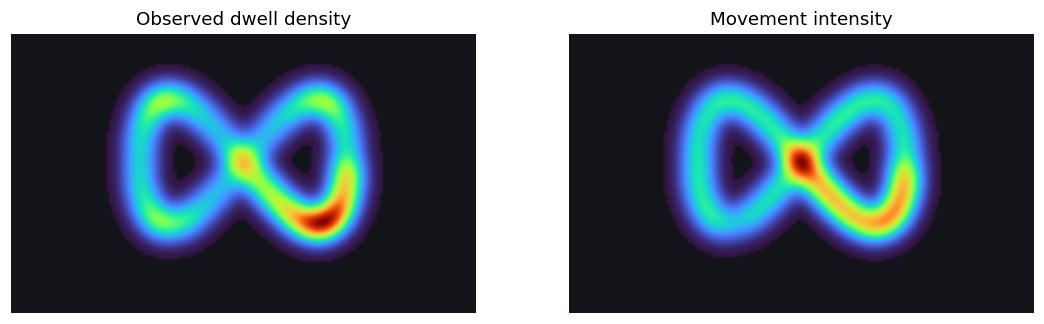

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, image, title in zip(axes, [dwell, activity], ["Observed dwell density", "Movement intensity"]):
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis("off")
plt.show()


## Experiment

In [4]:
short = heatmap(analyzer.history, (480, 800, 3), 239/30, 1)
print("Pixels that change with a 1-second window:", int(np.count_nonzero(short != dwell)))
assert not np.array_equal(short, dwell)
print("Trail segments:", sorted(set(p[3] for p in analyzer.trail)))


Pixels that change with a 1-second window: 400027
Trail segments: [0, 1]


## Observations
The colors are normalized independently for each map and should not be treated as a common numerical scale across sessions. Missing intervals do not add dwell.

## Conclusion
Trajectories and density maps describe different properties of movement.